In [1]:
# ==============================================================
# CELLA 1 — Setup e caricamento dati
# ==============================================================
 
%matplotlib inline
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm, skew, kurtosis, jarque_bera, anderson
from scipy.stats import t as student_t
import warnings
warnings.filterwarnings("ignore")
 
sp = pd.read_csv("../data/dailytotalreturn_S&P.csv")
sp["DlyCalDt"] = pd.to_datetime(sp["DlyCalDt"])
sp = sp.sort_values("DlyCalDt").reset_index(drop=True)
 
print(f"Dati caricati: {len(sp)} osservazioni")
print(f"Periodo: {sp['DlyCalDt'].min().date()} → {sp['DlyCalDt'].max().date()}")

Dati caricati: 8817 osservazioni
Periodo: 1990-01-02 → 2024-12-31


In [2]:
crisi = [
    ("Dot-com crash", "2000-03-01", "2002-10-31"),
    ("Crisi finanziaria",  "2008-09-01", "2009-03-31"),
    ("COVID crash",        "2020-02-01", "2020-04-30"),
]
 
# Costruzione maschera booleana
mask_crisi = pd.Series(False, index=sp.index)
for nome, inizio, fine in crisi:
    mask_crisi |= (
        (sp["DlyCalDt"] >= inizio) &
        (sp["DlyCalDt"] <= fine)
    )
 
# I due campioni
r_full    = sp["DlyTotRet"].values
r_nocrisi = sp.loc[~mask_crisi, "DlyTotRet"].values
 
n_escluse = mask_crisi.sum()
print(f"\nCampione completo:        {len(r_full):>5} osservazioni")
print(f"Osservazioni nei periodi di crisi: {n_escluse:>5} "
      f"({n_escluse/len(r_full)*100:.1f}%)")
print(f"Campione senza crisi:     {len(r_nocrisi):>5} osservazioni")
print()
for nome, inizio, fine in crisi:
    n = ((sp["DlyCalDt"] >= inizio) & (sp["DlyCalDt"] <= fine)).sum()
    print(f"  {nome:<22} {inizio} → {fine}  ({n} giorni)")


Campione completo:         8817 osservazioni
Osservazioni nei periodi di crisi:   879 (10.0%)
Campione senza crisi:      7938 osservazioni

  Dot-com crash          2000-03-01 → 2002-10-31  (671 giorni)
  Crisi finanziaria      2008-09-01 → 2009-03-31  (146 giorni)
  COVID crash            2020-02-01 → 2020-04-30  (62 giorni)


In [3]:
def descrittive(r, nome):
    return {
        "Campione":  nome,
        "N":         len(r),
        "Media":     round(r.mean(), 6),
        "Std":       round(r.std(), 6),
        "Skewness":  round(float(skew(r)), 4),
        "Kurtosis":  round(float(kurtosis(r)) + 3, 4),
        "Min":       round(r.min(), 4),
        "Max":       round(r.max(), 4),
    }
 
tab_desc = pd.DataFrame([
    descrittive(r_full,    "Completo"),
    descrittive(r_nocrisi, "Senza crisi"),
])
 
print("=" * 70)
print("TABELLA 1 — Statistiche descrittive: campione completo vs senza crisi")
print("=" * 70)
print(tab_desc.to_string(index=False))
print()
print("Nota: Kurtosis secondo definizione di Pearson (normale = 3)")
 
# Calcola la variazione della kurtosis
kurt_full    = float(kurtosis(r_full)) + 3
kurt_nocrisi = float(kurtosis(r_nocrisi)) + 3
riduzione    = (kurt_full - kurt_nocrisi) / kurt_full * 100
print(f"\nRiduzione kurtosis escludendo le crisi: "
      f"{kurt_full:.2f} → {kurt_nocrisi:.2f} "
      f"(-{riduzione:.1f}%)")
print("La kurtosis rimane ben superiore a 3 (normale) anche senza crisi.")

TABELLA 1 — Statistiche descrittive: campione completo vs senza crisi
   Campione    N    Media      Std  Skewness  Kurtosis     Min    Max
   Completo 8817 0.000466 0.011329   -0.1871   13.2816 -0.1190 0.1151
Senza crisi 7938 0.000610 0.009482   -0.2942    6.4610 -0.0679 0.0552

Nota: Kurtosis secondo definizione di Pearson (normale = 3)

Riduzione kurtosis escludendo le crisi: 13.28 → 6.46 (-51.4%)
La kurtosis rimane ben superiore a 3 (normale) anche senza crisi.


In [4]:
print("=" * 70)
print("TABELLA 2 — Test Jarque-Bera")
print("=" * 70)
print(f"{'Campione':<18} {'Statistica JB':>15} {'p-value':>10} {'Esito':>15}")
print("-" * 60)
for r_camp, nome in [(r_full, "Completo"), (r_nocrisi, "Senza crisi")]:
    jb_stat, jb_p = jarque_bera(r_camp)
    esito = "Rifiuto H0 ***" if jb_p < 0.001 else "Non rifiuto H0"
    print(f"{nome:<18} {jb_stat:>15.1f} {jb_p:>10.4f} {esito:>15}")
 
print()
print("=" * 70)
print("TABELLA 3 — Test Anderson-Darling")
print("=" * 70)
print(f"{'Campione':<18} {'Statistica AD':>14} {'VC 5%':>8} {'VC 1%':>8} {'Esito':>15}")
print("-" * 65)
for r_camp, nome in [(r_full, "Completo"), (r_nocrisi, "Senza crisi")]:
    ad = anderson(r_camp, dist="norm")
    vc_5 = ad.critical_values[2]   # indice 2 = livello 5%
    vc_1 = ad.critical_values[4]   # indice 4 = livello 1%
    esito = "Rifiuto H0 ***" if ad.statistic > vc_1 else "Rifiuto H0 *"
    print(f"{nome:<18} {ad.statistic:>14.2f} {vc_5:>8.3f} {vc_1:>8.3f} {esito:>15}")
 
print()
print("H0: i rendimenti seguono una distribuzione normale")
print("***: rifiuto al livello 1%")

TABELLA 2 — Test Jarque-Bera
Campione             Statistica JB    p-value           Esito
------------------------------------------------------------
Completo                   38887.0     0.0000  Rifiuto H0 ***
Senza crisi                 4076.3     0.0000  Rifiuto H0 ***

TABELLA 3 — Test Anderson-Darling
Campione            Statistica AD    VC 5%    VC 1%           Esito
-----------------------------------------------------------------
Completo                   147.96    0.787    1.092  Rifiuto H0 ***
Senza crisi                 71.83    0.787    1.091  Rifiuto H0 ***

H0: i rendimenti seguono una distribuzione normale
***: rifiuto al livello 1%


In [5]:
print("=" * 70)
print("TABELLA 4 — Fitting t di Student (MLE)")
print("=" * 70)
print(f"{'Campione':<18} {'ν (gradi libertà)':>18} {'σ_t (scala)':>12} {'Note':>25}")
print("-" * 75)
for r_camp, nome in [(r_full, "Completo"), (r_nocrisi, "Senza crisi")]:
    df_t, loc_t, scale_t = student_t.fit(r_camp, floc=0)
    if df_t < 3:
        nota = "kurtosis infinita (ν<3)"
    elif df_t < 4:
        nota = "kurtosis infinita (ν<4)"
    elif df_t < 6:
        nota = "code molto pesanti"
    else:
        nota = "code moderate"
    print(f"{nome:<18} {df_t:>18.4f} {scale_t:>12.6f} {nota:>25}")
 
print()
print("Interpretazione: ν < 4 implica kurtosis teorica infinita.")
print("Anche senza le crisi, ν resta basso — le code pesanti")
print("sono una proprietà strutturale del processo, non un")
print("artefatto dei soli periodi di stress.")

TABELLA 4 — Fitting t di Student (MLE)
Campione            ν (gradi libertà)  σ_t (scala)                      Note
---------------------------------------------------------------------------
Completo                       2.8781     0.006881   kurtosis infinita (ν<3)
Senza crisi                    3.6467     0.006708   kurtosis infinita (ν<4)

Interpretazione: ν < 4 implica kurtosis teorica infinita.
Anche senza le crisi, ν resta basso — le code pesanti
sono una proprietà strutturale del processo, non un
artefatto dei soli periodi di stress.


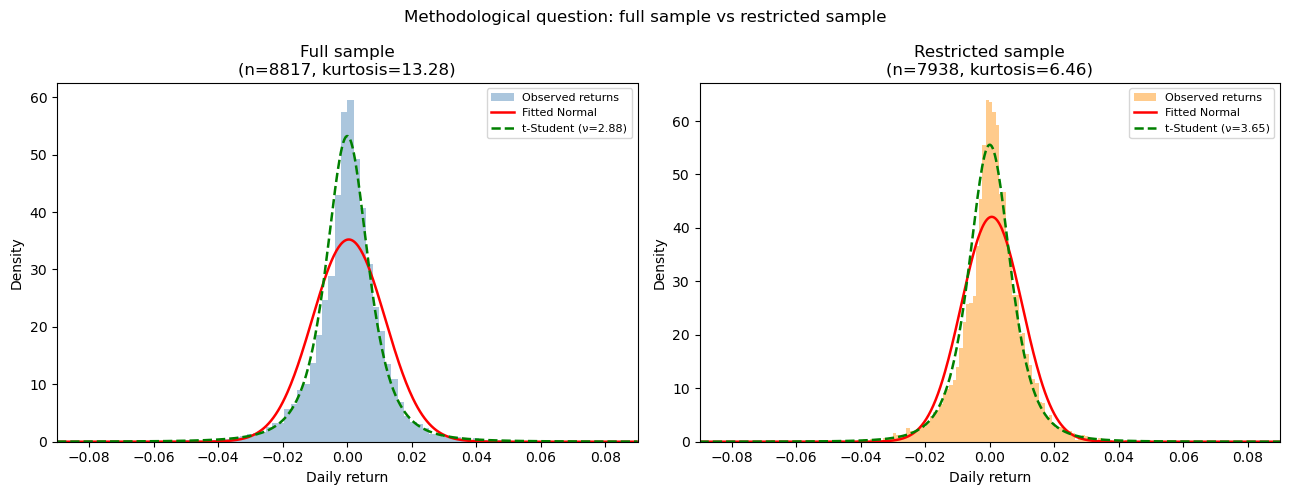

Grafico salvato: nodo_crisi_istogrammi.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Methodological question: full sample vs restricted sample",
    fontsize=12
)
 
for ax, (r_camp, nome, colore) in zip(axes, [
    (r_full,    "Full sample",        "steelblue"),
    (r_nocrisi, "Restricted sample",     "darkorange"),
]):
    df_t, loc_t, scale_t = student_t.fit(r_camp, floc=0)
    mu, sigma = r_camp.mean(), r_camp.std()
 
    x = np.linspace(-0.09, 0.09, 500)
    pdf_n = norm.pdf(x, mu, sigma)
    pdf_t = student_t.pdf(x, df_t, loc_t, scale_t)
 
    ax.hist(r_camp, bins=120, density=True,
            color=colore, alpha=0.45, label="Observed returns")
    ax.plot(x, pdf_n, "r-",  lw=1.8, label="Fitted Normal")
    ax.plot(x, pdf_t, "g--", lw=1.8, label=f"t-Student (ν={df_t:.2f})")
 
    kurt = float(kurtosis(r_camp)) + 3
    ax.set_xlim(-0.09, 0.09)
    ax.set_xlabel("Daily return")
    ax.set_ylabel("Density")
    ax.set_title(f"{nome}\n(n={len(r_camp)}, kurtosis={kurt:.2f})")
    ax.legend(fontsize=8)
 
plt.tight_layout()
plt.savefig("nodo_crisi_istogrammi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico salvato: nodo_crisi_istogrammi.png")

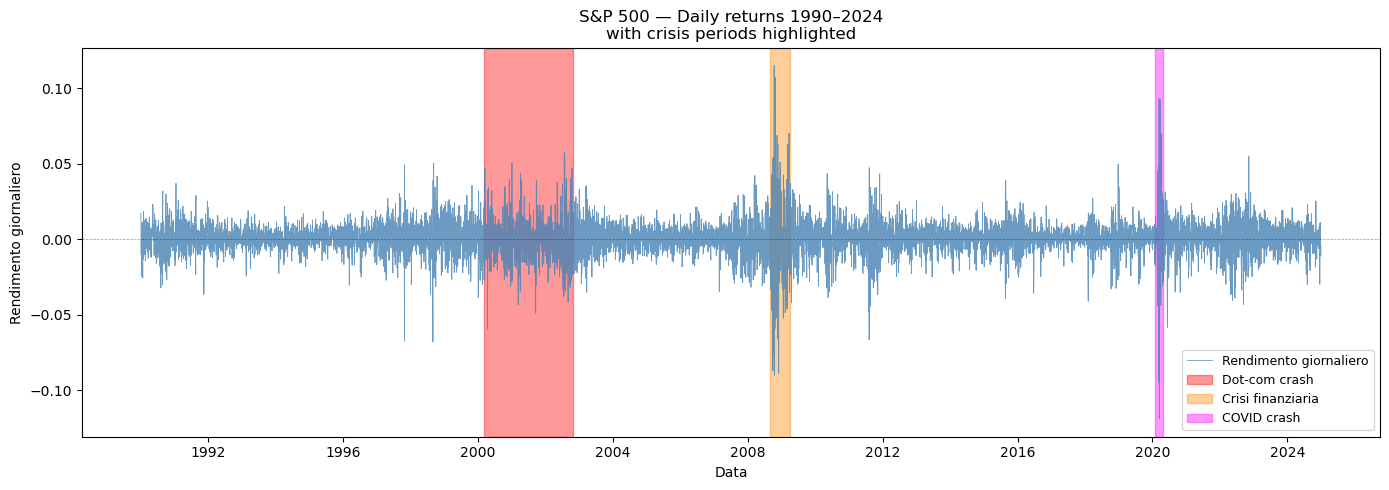

Grafico salvato: nodo_crisi_serie_storica.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
 
ax.plot(sp["DlyCalDt"], sp["DlyTotRet"],
        color="steelblue", lw=0.6, alpha=0.8, label="Rendimento giornaliero")
 
colori_crisi = ["#FF000033", "#FF880033", "#FF00FF33"]
for (nome, inizio, fine), colore in zip(crisi, colori_crisi):
    ax.axvspan(
        pd.to_datetime(inizio),
        pd.to_datetime(fine),
        color=colore, alpha=0.4, label=nome
    )
 
ax.axhline(0, color="black", lw=0.5, linestyle="--", alpha=0.4)
ax.set_xlabel("Data")
ax.set_ylabel("Rendimento giornaliero")
ax.set_title(
    "S&P 500 — Daily returns 1990–2024\n"
    "with crisis periods highlighted"
)
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("nodo_crisi_serie_storica.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico salvato: nodo_crisi_serie_storica.png")
 

In [8]:
print("=" * 70)
print("TABELLA RIASSUNTIVA — da inserire in tesi (Capitolo 3)")
print("=" * 70)
 
righe = []
for r_camp, nome in [(r_full, "Completo"), (r_nocrisi, "Senza crisi")]:
    df_t, _, _ = student_t.fit(r_camp, floc=0)
    jb_stat, jb_p = jarque_bera(r_camp)
    ad_stat = anderson(r_camp, dist="norm").statistic
    righe.append({
        "Campione":       nome,
        "N":              len(r_camp),
        "Kurtosis":       round(float(kurtosis(r_camp)) + 3, 2),
        "Skewness":       round(float(skew(r_camp)), 4),
        "ν (t-Student)":  round(df_t, 4),
        "JB statistic":   round(jb_stat, 1),
        "AD statistic":   round(ad_stat, 2),
        "H0 (normalità)": "Rifiutata ***",
    })
 
tab_final = pd.DataFrame(righe)
print(tab_final.to_string(index=False))
tab_final.to_csv("nodo_crisi_risultati.csv", index=False)
 
print()
print("CONCLUSIONE METODOLOGICA:")
print("-" * 70)
print("L'ipotesi di normalità viene rifiutata con p-value = 0 su entrambi")
print("i campioni. La kurtosis rimane significativamente superiore a 3 e")
print("ν resta basso anche escludendo i periodi di crisi. Questo implica")
print("che le code pesanti sono una proprietà strutturale del processo")
print("generatore dei rendimenti, non un artefatto dei soli episodi di")
print("stress finanziario. Escludere le crisi equivarrebbe ad assumere")
print("che esse siano shock puramente esogeni — un'ipotesi teorica forte")
print("che i dati non supportano (Cont, 2001; Mandelbrot, 1963).")
print()
print("File salvati:")
print("  nodo_crisi_istogrammi.png")
print("  nodo_crisi_serie_storica.png")
print("  nodo_crisi_risultati.csv")

TABELLA RIASSUNTIVA — da inserire in tesi (Capitolo 3)
   Campione    N  Kurtosis  Skewness  ν (t-Student)  JB statistic  AD statistic H0 (normalità)
   Completo 8817     13.28   -0.1871         2.8781       38887.0        147.96  Rifiutata ***
Senza crisi 7938      6.46   -0.2942         3.6467        4076.3         71.83  Rifiutata ***

CONCLUSIONE METODOLOGICA:
----------------------------------------------------------------------
L'ipotesi di normalità viene rifiutata con p-value = 0 su entrambi
i campioni. La kurtosis rimane significativamente superiore a 3 e
ν resta basso anche escludendo i periodi di crisi. Questo implica
che le code pesanti sono una proprietà strutturale del processo
generatore dei rendimenti, non un artefatto dei soli episodi di
stress finanziario. Escludere le crisi equivarrebbe ad assumere
che esse siano shock puramente esogeni — un'ipotesi teorica forte
che i dati non supportano (Cont, 2001; Mandelbrot, 1963).

File salvati:
  nodo_crisi_istogrammi.png
  no

In [9]:
# ==============================================================
# Chi-square goodness-of-fit test su entrambi i campioni
# ==============================================================

from scipy.stats import norm, chi2
import numpy as np

def chi_square_normality(r, k=10):
    mu, sigma = r.mean(), r.std()
    
    # Quantili equiprobabili sotto la normale
    quantiles = norm.ppf(np.linspace(0.001, 0.999, k+1), loc=mu, scale=sigma)
    
    # Frequenze osservate
    observed, _ = np.histogram(r, bins=quantiles)
    
    # Frequenze attese (equiprobabili)
    expected = np.ones(k) * len(r) / k
    
    # Statistica chi-square
    chi_stat = np.sum((observed - expected)**2 / expected)
    
    # Gradi di libertà: k - 1 - 2 (stimo mu e sigma)
    df = k - 1 - 2
    
    # p-value
    p_value = 1 - chi2.cdf(chi_stat, df)
    
    return chi_stat, p_value

# Campione completo
chi_full, p_full = chi_square_normality(r_full)
print(f"Chi-square completo:    statistica = {chi_full:.2f}, p-value = {p_full:.4f}")

# Campione senza crisi
chi_nocrisi, p_nocrisi = chi_square_normality(r_nocrisi)
print(f"Chi-square senza crisi: statistica = {chi_nocrisi:.2f}, p-value = {p_nocrisi:.4f}")

Chi-square completo:    statistica = 1184.23, p-value = 0.0000
Chi-square senza crisi: statistica = 633.56, p-value = 0.0000
